In [99]:
# Loading libraries
suppressPackageStartupMessages({
    library(tidyverse) # Give ggplot, read_delim, tidyr, etc.
    library(janitor) # Gives tabyl
    library(gplots) # Gives plotmeans
    library(ggstatsplot) # Gives pretty plotting
    library(car) # Gives Anova
    library(Hmisc) # Gives mean_cl_boot
    library(dplyr) # Gives join, mutate, filter, etc.
})
options(width=200) # set the display width to 200 characters


### Loading and cleaning data

In [100]:
load_questionnaire_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)
  # Drop unwanted columns
  df <- df %>% select(
    -c(
      Surname,
      `First name`,
      State,
      `Started on`,
      Completed,
      `Grade/10.00`,
      `Time taken`,
    )
  )

  # Rename columns
  df <- df %>%
    rename(
      email = `Email address`,
      gender = `Response 1`,
      age = `Response 2`,
      academic_level = `Response 3`,
      academic_field = `Response 4`,
      parents_education = `Response 5`,
      sport = `Response 6`
    )

  return(df)
}


load_pretest_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Keep and rename specific columns
  df <- df %>%
    select(
      email = `Email address`,
      time_pretest = `Time taken`,
      grade_pretest = `Grade/9.00`
    )

  return(df)
}

load_posttest1_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Keep and rename specific columns
  df <- df %>%
    select(
      email = `Email address`,
      time_posttest = `Time taken`,
      grade_posttest = `Grade/9.00`
    )

  return(df)
}

load_posttest2_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)

  # Drop unwanted columns
  df <- df %>% select(
    -c(
      Surname,
      `First name`,
      State,
      `Started on`,
      Completed,
      `Grade/7.00`,
      `Time taken`
    )
  )

  # Rename columns
  df <- df %>%
    rename(
      email = `Email address`,
      comfort_before       = `Response 1`,
      comfort_after        = `Response 2`,
      comfort_explanation  = `Response 3`,
      confidence           = `Response 4`,
      perceived_learning   = `Response 5`,
      learning_explanation = `Response 6`,
      comments             = `Response 7`
    )

  return(df)
}

convert_time_to_seconds <- function(time_str) {
  mins <- as.numeric(str_extract(time_str, "\\d+(?=\\s*mins?)"))
  secs <- as.numeric(str_extract(time_str, "\\d+(?=\\s*secs?)"))
  mins[is.na(mins)] <- 0
  secs[is.na(secs)] <- 0
  total_seconds <- mins * 60 + secs
  return(total_seconds)
}

load_psactv_data <- function(file_path) {
  # Read CSV
  df <- read.csv(file_path, check.names = FALSE)
  # Keep and rename specific columns
  df <- df %>%
    select(
      email = `email`,
      correct = `Correct`,
      algorithmic = `Algorithmic`,
      graph_used = `Graph_used`
    )

  return(df)
}

In [101]:
# Load data from csv files
questionnaire_psi = load_questionnaire_data("data/questionnaire_psi.csv")
questionnaire_ips = load_questionnaire_data("data/questionnaire_ips.csv")
pretest_psi = load_pretest_data("data/pretest_psi.csv")
pretest_ips = load_pretest_data("data/pretest_ips.csv")
posttest1_psi = load_posttest1_data("data/posttest1_psi.csv")
posttest1_ips = load_posttest1_data("data/posttest1_ips.csv")
posttest2_psi = load_posttest2_data("data/posttest2_psi.csv")
posttest2_ips = load_posttest2_data("data/posttest2_ips.csv")
psactv_psi = load_psactv_data("data/PS_activity_psi.csv")
psactv_ips = load_psactv_data("data/PS_activity_ips.csv")

In [ ]:
# PSI group
psi_data <- posttest1_psi %>%
  inner_join(questionnaire_psi, by = "email") %>%
  left_join(pretest_psi, by = "email") %>%
  left_join(posttest2_psi, by = "email") %>%
  left_join(psactv_psi, by = "email") %>%
  mutate(group = "psi") %>%
  select(-email)

# IPS group
ips_data <- posttest1_ips %>%
  inner_join(questionnaire_ips, by = "email") %>%
  left_join(pretest_ips, by = "email") %>%
  left_join(posttest2_ips, by = "email") %>%
  left_join(psactv_ips, by = "email") %>%
  mutate(group = "ips") %>%
  select(-email)


psi_data$grade_pretest <- as.numeric(psi_data$grade_pretest)
ips_data$grade_pretest <- as.numeric(ips_data$grade_pretest)

# Combine both
final_data <- bind_rows(psi_data, ips_data)

final_data <- final_data %>%
  mutate(
    time_pretest = convert_time_to_seconds(time_pretest),
    time_posttest = convert_time_to_seconds(time_posttest), 
  )

# Encode academic_level col to  a new col (academic_level_compressed = (Bachelor, Master, Phd = 0, 1, 2))
# + Encode academic_field col to (Non-science (0), Scienec(1))) & CS / non-cs
final_data <- final_data %>%
  mutate(academic_level_compressed = case_when(
    str_detect(tolower(academic_level), "phd|doctorate") ~ 2,
    str_detect(tolower(academic_level), "master") ~ 1,
    str_detect(tolower(academic_level), "bachelor") ~ 0,
    TRUE ~ NA_real_  # Assign NA if none of the keywords are found
  ))
final_data <- final_data %>%
  mutate(science = case_when(
    str_detect(tolower(academic_field), "science|engineering|mathematics|medicine|cybersecurity|medical|neuro-x|physics|sie") ~ 1,
    TRUE ~ 0 
  ))
final_data <- final_data %>%
  mutate(CS = case_when(
    str_detect(tolower(academic_field), "computer|software") ~ 1,
    TRUE ~ 0  
  ))
# Save the final data
write.csv(final_data, "data/final_data.csv", row.names = FALSE)
# Print the first few rows of the final data
print(head(final_data))

 [1] 1 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0


### Dependent variable: Relative learning gain

In [103]:
# Calculate the relative learning gain
calculate_rlg = function(df, pre_col = "grade_pretest", post_col = "grade_posttest", max_score = 9) {
  df = df %>%
    mutate(
      !!pre_col := as.numeric(.data[[pre_col]]),
      !!post_col := as.numeric(.data[[post_col]]),
      rel_learning_gain = round((.data[[post_col]] - .data[[pre_col]]) / (max_score - .data[[pre_col]]), 2)
    )
  return(df)
}

df_combined = calculate_rlg(final_data)

head(df_combined)


,time_posttest,grade_posttest,gender,age,academic_level,academic_field,parents_education,sport,time_pretest,grade_pretest,...,comfort_explanation,confidence,perceived_learning,learning_explanation,comments,correct,algorithmic,graph_used,group,rel_learning_gain
,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<dbl>
1,471,9.0,Female,18-22 years old,Master,Computer Science,University,Gym 2-3 times a week,259,7.0,...,"I felt unsure during the pre-test because, while I have seen Dijkstra before, I forgot how the algorithm worked and could not answer the questions that required an understanding of the exact steps before watching the video (e.g. which node is processed when). It was easy to answer the questions where you just have to find the shortest path because it doesn't require an understanding of Dijkstra in particular.",Somewhat Confident,Definitely,I learn best by following examples which the instruction provided.,-,1,1,1,psi,1.00
2,354,9.0,Male,18-22 years old,Master,Computer Science (and Math for bachelor),High school,"Ultimate frisbee and Bouldering, about once a week in total",353,7.0,...,NA,NA,NA,NA,NA,1,2,0,psi,1.00
3,307,9.0,Male,More than 25 years old,Master,Applied Mathematics,University,Yes. Running twice a week,227,5.5,...,in the lesson i learned about the detailed steps of the algorithm,Somewhat Confident,Definitely,the video was clear,-,1,1,1,psi,1.00
4,388,6.1,Female,More than 25 years old,Bachelor,Environmental Laws and International Relations,High school,Long Walks- twice a week,601,1.2,...,The video explanation being in parts would have made understanding the new concept easier.,Not Very Confident,Definitely,The different methods to solve one problem is efficient in understanding a new concept.,Great Work! I would like to see the same conducted on a hybrid system where some tests are done to asses knowledge level before access to the content and then tests after the content.,1,0,0,psi,0.63
5,534,5.5,Male,23-25 years old,Bachelor,Computer Science,University,Yes. I normally do morning runs every Saturday of the week.,602,4.5,...,This is because I gathered more insights on the Dijkstra's algorithm through the video explanation.,Confident,Not so sure,This was a new topic unrelated to sorting lists I had done before,Good challenge for sure.,1,1,0,psi,0.22
6,369,6.5,Female,More than 25 years old,Bachelor,Environmental Science,University,"Walks, at least twice a week",487,4.2,...,"Before the activity, i had no idea what Dijkstra's algorithm was and how to use it, but for the post test it was a bit more clearer",Somewhat Confident,Kind of,"Since the topic is new to me, i learnt some things, but there was no way to clarify my confusion",-,1,1,0,psi,0.48


### Checking ANOVA Assumptions

In [184]:
# Normality test for residuals (Shapiro-Wilk test)
model.0 <- lm(rel_learning_gain ~ group, 
              contrasts=list(group=contr.sum),
              data=df_combined)
summary(model.0)
shapiro.test(model.0$residuals)
# Results, we succeed the very sensitive Shapiro-Wilk test


Call:
lm(formula = rel_learning_gain ~ group, data = df_combined, contrasts = list(group = contr.sum))

Residuals:
   Min     1Q Median     3Q    Max 
-0.923 -0.170 -0.020  0.350  0.537 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.55650    0.07988   6.967 1.23e-06 ***
group1      -0.09350    0.07988  -1.170    0.256    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3656 on 19 degrees of freedom
Multiple R-squared:  0.06726,	Adjusted R-squared:  0.01817 
F-statistic:  1.37 on 1 and 19 DF,  p-value: 0.2563



	Shapiro-Wilk normality test

data:  model.0$residuals
W = 0.94065, p-value = 0.2244


In [105]:
# Normality test (Kolmogorov-Smirnov test)
x <- model.0$residuals
ks.test(x, "pnorm", mean(x, na.rm = T), sd(x, na.rm = T))
# Results, we succeed 

Warning message in ks.test.default(x, "pnorm", mean(x, na.rm = T), sd(x, na.rm = T)):
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  x
D = 0.16116, p-value = 0.6465
alternative hypothesis: two-sided


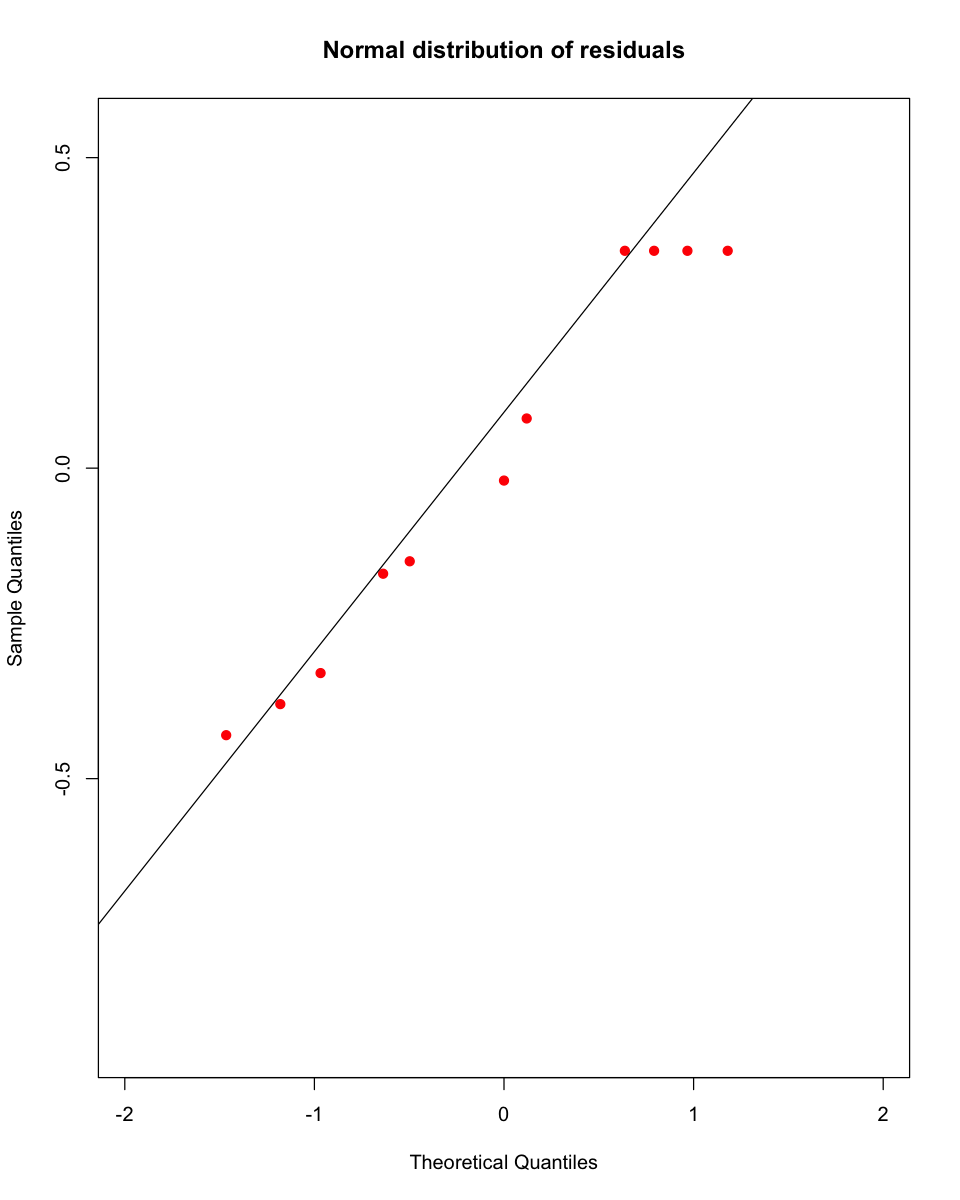

In [106]:
# Normality test (Visual test - more recommended by most of textbooks)
options(repr.plot.width=8, repr.plot.height=10)
group_colors <- c("psi" = "red", "control" = "blue")
qqnorm(model.0$residuals, col=group_colors[df_combined$group], pch=19, 
       main="Normal distribution of residuals")
qqline(model.0$residuals)
# Results, we succeed 

In [107]:
# Checking homoscedasticity (Bartlett test)
# We can use the Bartlett test for homogeneity of variances
bartlett.test(residuals(model.0) ~ df_combined$group)
# Results, we succeed with a p-value of 0.4019 close to the value in Patrick scripts of 0.58


	Bartlett test of homogeneity of variances

data:  residuals(model.0) by df_combined$group
Bartlett's K-squared = 0.70265, df = 1, p-value = 0.4019


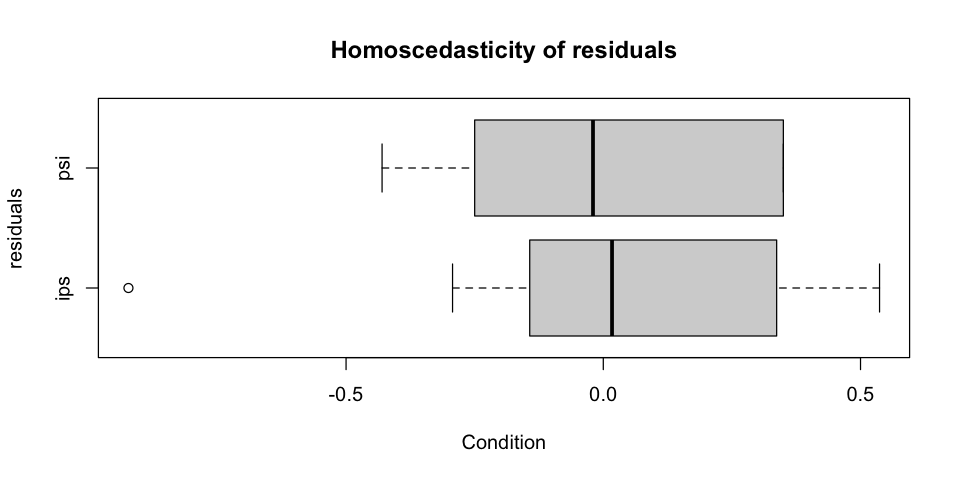

In [108]:
# Checking homoscedasticity (Visual test)
options(repr.plot.width=8, repr.plot.height=4)
boxplot(model.0$residuals ~ df_combined$group, 
        main="Homoscedasticity of residuals",
        ylab="residuals",
        xlab="Condition", horizontal=TRUE)

### Learning Gain Visulatization (PSI has higher learning gain than IPS)

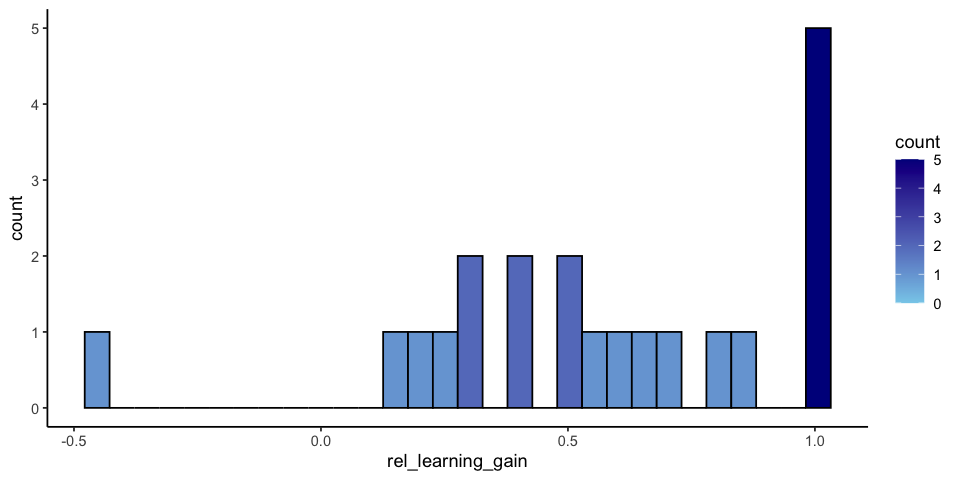

In [185]:
# All learning gains
df_combined %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  theme_classic()


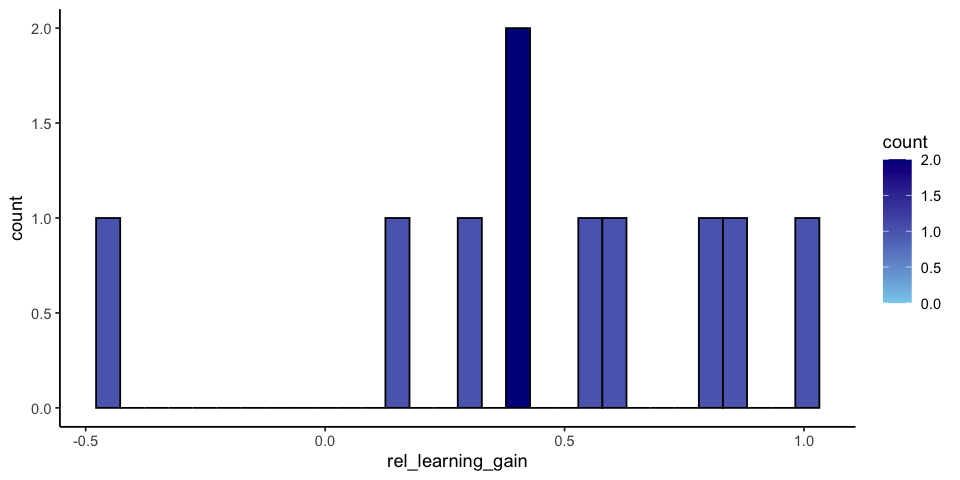

In [110]:
# IPS learning gains
df_combined %>%
  filter(group == "ips") %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  theme_classic()

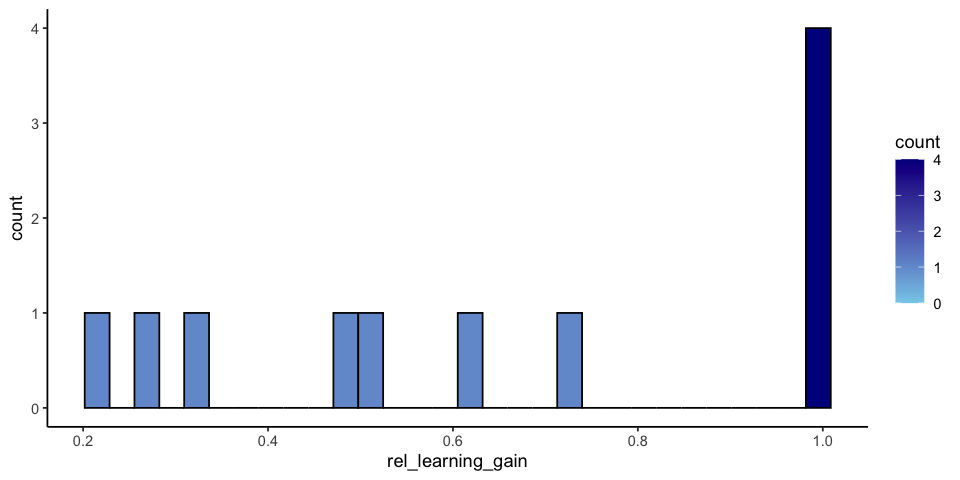

In [111]:
# PSI learning gains
df_combined %>%
  filter(group == "psi") %>%
  ggplot(aes(x = rel_learning_gain, fill = ..count..)) +
  geom_histogram(bins = 30, color = "black") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  theme_classic()

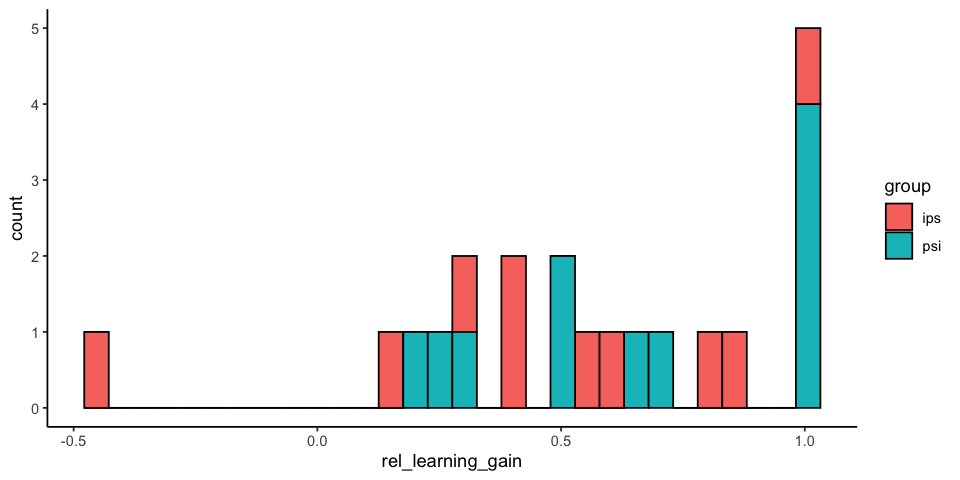

In [112]:
# learning gains per group
df_combined %>%
  ggplot(aes(x = rel_learning_gain, fill = group)) +
  geom_histogram(bins = 30, color = "black") +
  theme_classic()

### Participants Data Visualization

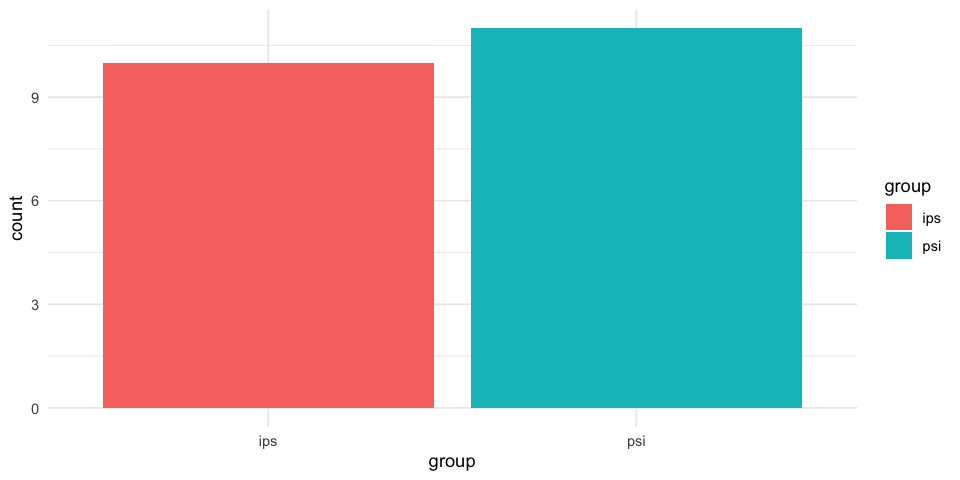

In [113]:
# number of participants per group
ggplot(df_combined, aes(x = group, fill = group)) +
  geom_bar() +
  theme_minimal()

## Control variables

#### Gender and condition

In [114]:
# Create a contingency table of group (psi vs ips) vs gender
df_combined %>%
  tabyl(group, gender)

# Run a chi-squared test on the same contingency table
df_combined %>%
  tabyl(group, gender) %>%
  chisq.test()

group,Female,Male
<chr>,<dbl>,<dbl>
ips,6,4
psi,7,4


Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test with Yates' continuity correction

data:  .
X-squared = 0, df = 1, p-value = 1


The chi-squared test for gender shows no significant difference between the psi and ips groups (X² = 0, p = 1). This indicates that the groups are balanced with respect to this control variable, reducing the likelihood that it will confound the main analysis. Therefore, differences observed in the outcome are unlikely to be explained by this control variable.

#### Academic level and condition

In [ ]:
df_combined %>%
  tabyl(group, academic_level) %>%
  chisq.test()

table(df_combined$group, df_combined$academic_level)

Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 4.9636, df = 6, p-value = 0.5485


     
      Bachelor Doctorate Got my MSc, currently PhD student Master PhD bachelor second year master
  ips        4         1                                 0      4   0                    1      0
  psi        4         0                                 1      4   1                    0      1

 [1] "Master"                            "Master"                            "Master"                            "Bachelor"                          "Bachelor"                         
 [6] "Bachelor"                          "Got my MSc, currently PhD student" "Master"                            "Bachelor"                          "master"                           
[11] "PhD"                               "Master"                            "Bachelor"                          "Master"                            "Bachelor"                         
[16] "Doctorate"                         "Bachelor"                          "Master"                            "Master"                            "Bachelor"                         
[21] "bachelor second year"             


The chi-squared test shows that there is no statistically significant association between the groups and academic level.

#### Academic field and condition

In [116]:
df_combined %>%
  tabyl(group, academic_field) %>%
  chisq.test()

table(df_combined$group, df_combined$academic_field)

Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 21, df = 19, p-value = 0.3368


     
      Applied Mathematics Computer Engineering Computer Science Computer Science (and Math for bachelor) Cybersecurity Economics Engineering and Entrepreneurship
  ips                   0                    0                0                                        0             1         0                                1
  psi                   1                    1                2                                        1             0         1                                0
     
      Environmental Laws and International Relations Environmental Science Life Sciences Engineering Mathematics Mechanical engineering Medical Biotechnology Medicine Micro-Engineering Neuro-X SIE
  ips                                              0                     0                         0           1                      1                     1        1                 1       1   0
  psi                                              1                     1                         1        

The chi-squared test shows that there is no statistically significant association between the groups and academic field.

### Parents' education level and condition

In [117]:
df_combined %>%
  tabyl(group, parents_education) %>%
  chisq.test()

table(df_combined$group, df_combined$parents_education)

Warning message in stats::chisq.test(., ...):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  .
X-squared = 4.492, df = 2, p-value = 0.1058


     
      High school Primary school University
  ips           0              0         10
  psi           3              1          7

The chi-squared test shows that there is no statistically significant association between the groups and parents' academic level.

## Plots: Learning Gain by Group


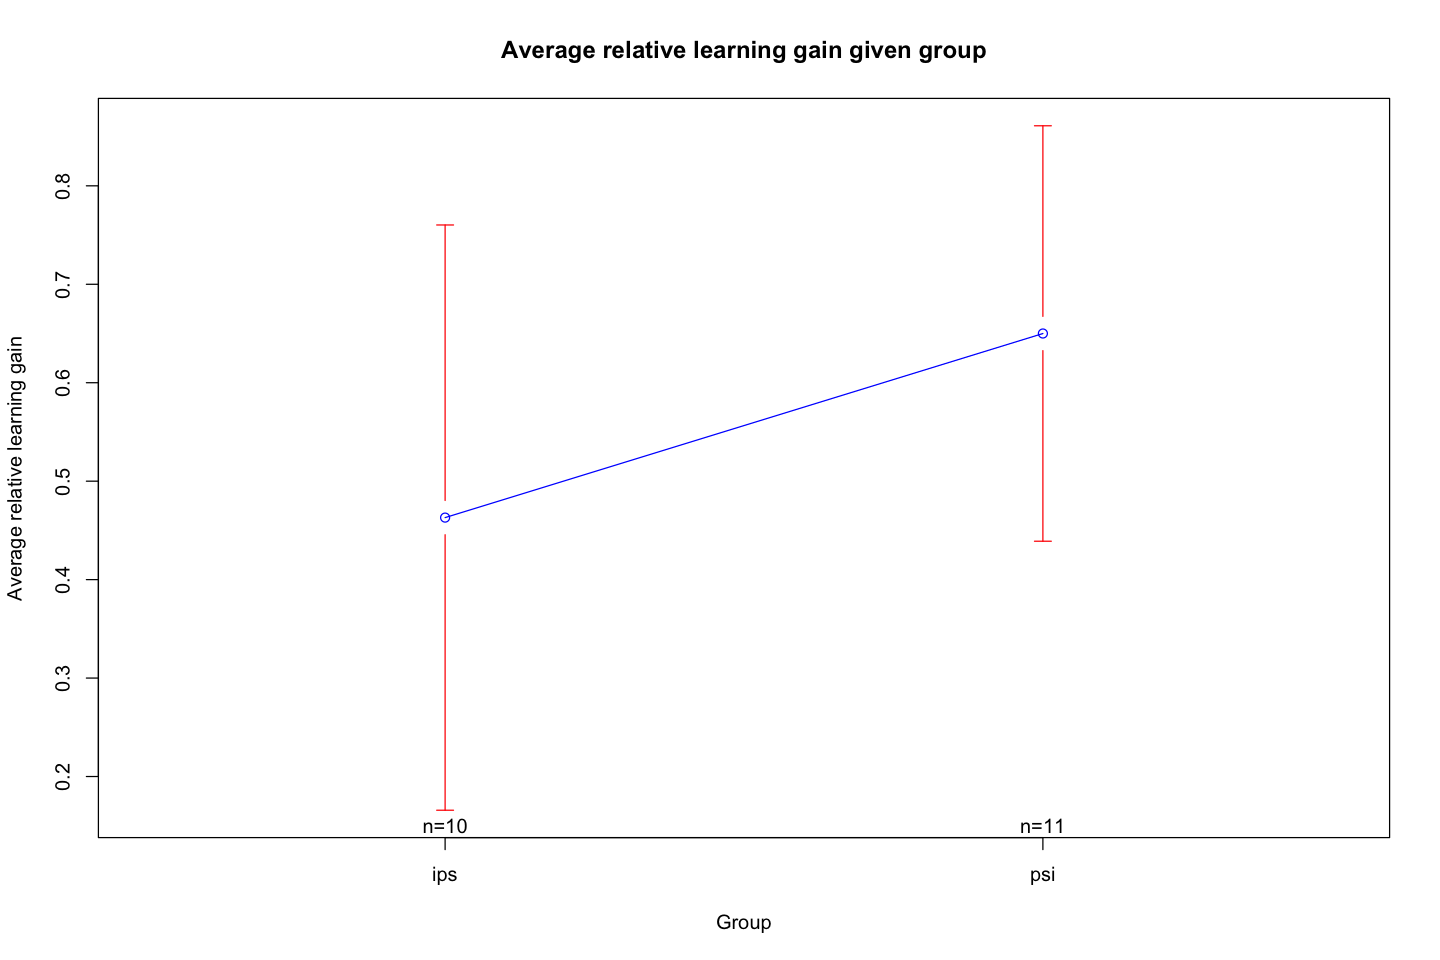

In [118]:
options(repr.plot.width=12, repr.plot.height=8)

# Set white background
par(bg = "white")

plotmeans(rel_learning_gain ~ group, 
          main="Average relative learning gain given group",
          ylab="Average relative learning gain",
          xlab="Group",
          data=df_combined,
          col="blue",
          barcol="red")

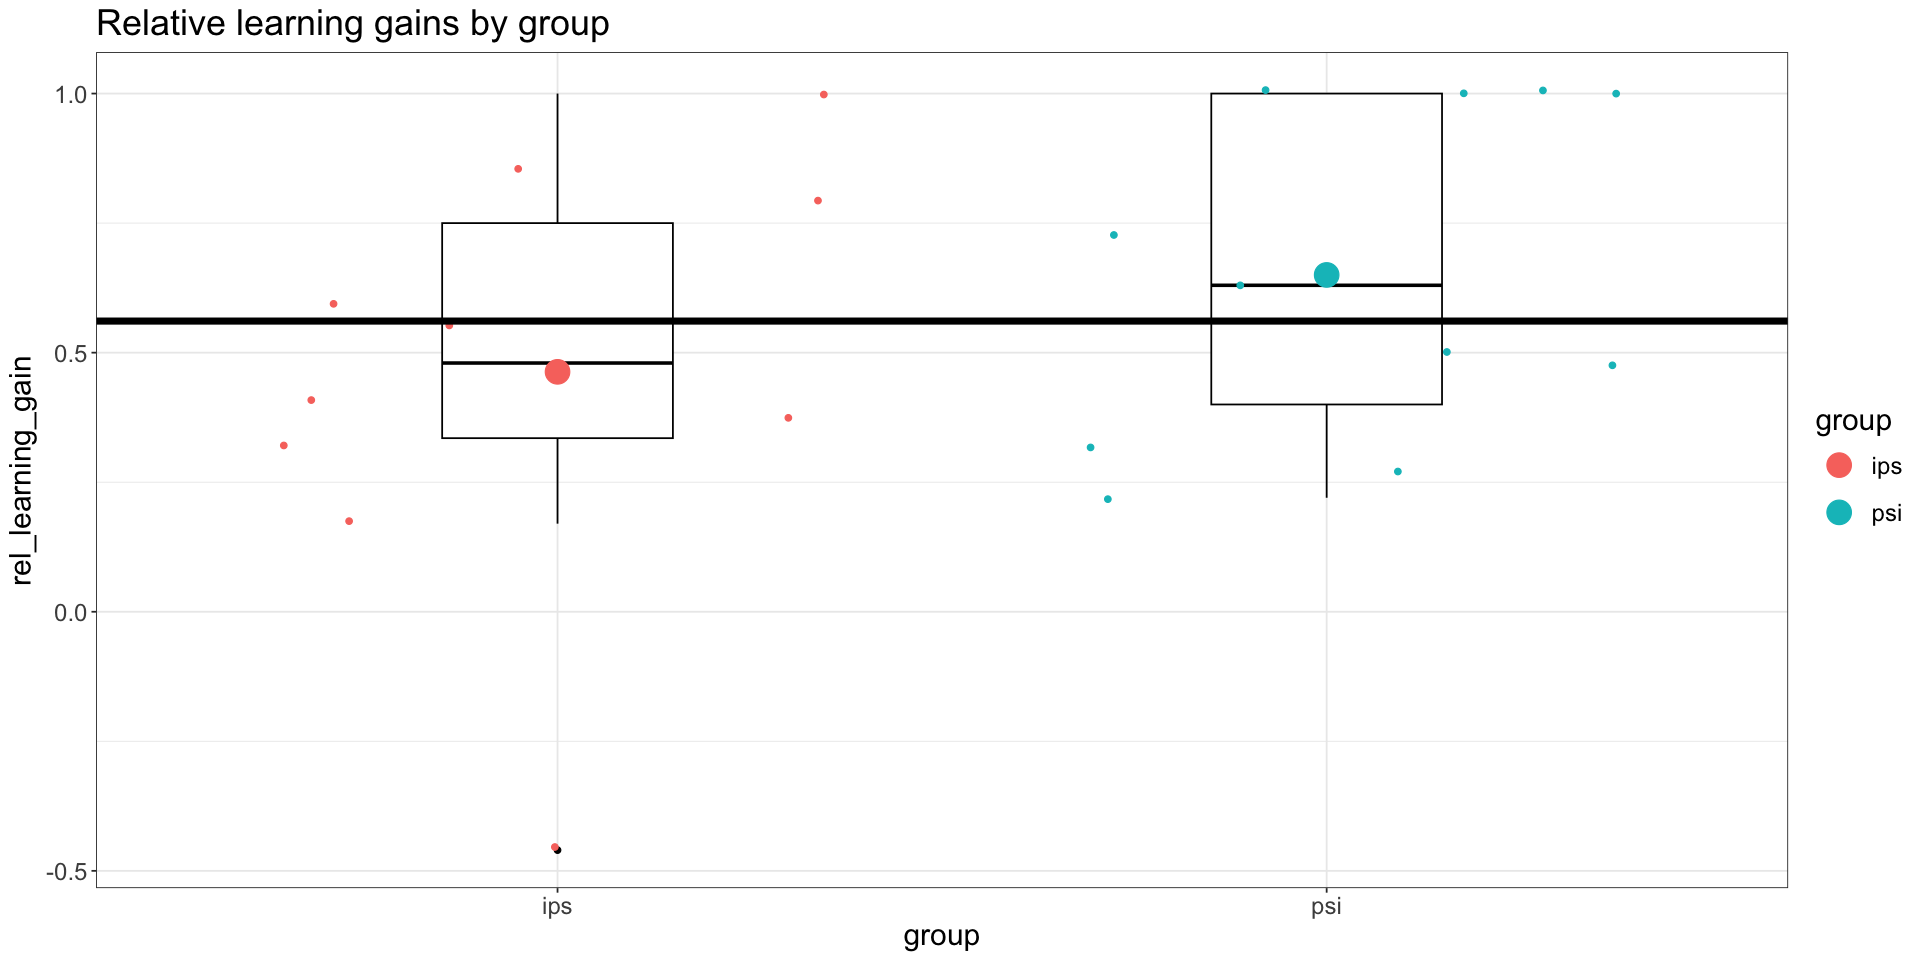

In [119]:
options(repr.plot.width=16, repr.plot.height=8)
df_combined %>% ggplot() +
    aes(x = group, y = rel_learning_gain, color = group) +
    geom_boxplot(color = "black", width = 0.3) +
    geom_jitter() +
    stat_summary(fun=mean, 
        #color="black",
        geom="point",
        group=1,
        shape=20, 
        size=10, 
    ) +
    theme_bw() +
    labs(title = "Relative learning gains by group") +
    theme(text = element_text(size = 18)) +
    geom_hline(aes(yintercept = mean(rel_learning_gain)), linewidth=2, color = "black") 

## ANOVA test with one factor (manual)

### Sum of squares

In [120]:
# Calculate the average relative learning gain
ave_rel_learning_gain = mean(df_combined$rel_learning_gain)
ave_rel_learning_gain

[1] 0.5609524

In [121]:
# Calculate the sum of squares total
ss_total = sum((df_combined$rel_learning_gain - ave_rel_learning_gain)^2)
ss_total

[1] 2.723381

In [122]:
# Calculate the sum of squares within groups
within_ss = function(x) {
    sum((x - mean(x))^2)
}
ss_within = sum(tapply(df_combined$rel_learning_gain, df_combined$group, within_ss))
ss_within

mss_within = ss_within / (length(df_combined$rel_learning_gain) - 2) # N - k groups
mss_within 

[1] 2.54021

[1] 0.1336953

In [123]:
# Calculate the sum of squares between groups
between_ss = function(x) {
    sum(length(x)*(mean(x) - ave_rel_learning_gain)^2)
}

ss_between = sum(tapply(df_combined$rel_learning_gain, df_combined$group, between_ss))
ss_between

mss_between = ss_between / 1 # (k groups - 1)
mss_between 

[1] 0.183171

[1] 0.183171

### F-ratio

In [124]:
# Compute the ratio of the between group variance to the within group variance
F = mss_between / mss_within
F

[1] 1.370063

In [125]:
no_obs = nrow(df_combined)
df = no_obs - 2 # degrees of freedom

### p-value

In [126]:
# pf gives the probability of getting an F value greater than F
p.value = pf(F, 1, df, lower.tail = FALSE)
p.value

[1] 0.2562734

In [127]:
alpha = 0.05
F.critical = qf(1-alpha, df1=1, df2=df) 
F.critical

[1] 4.38075

## ANOVA test with one factor (non-manual)

In [128]:
library(car) # load library car first.
Anova(model.0, type="II")

,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
group,0.183171,1,1.370063,0.2562734
Residuals,2.540210,19,NA,NA


We get an F-ratio of 1.370063 and a p-value of 0.2562734 > 0.05, so we can't reject the null hypothesis

## Power Analysis (was our test given the sample size powerful enough to detect an effect if it exists?)

In [129]:
library(pwr)
pwr.anova.test(k = 2,            # Number of groups
               n = 10.5,           # Sample size per group
               f = 0.25,         # Effect size (Cohen's f)
               sig.level = 0.05, # Alpha level
               power = NULL)     # R will calculate this
# we get a small power of power = 0.1928624


     Balanced one-way analysis of variance power calculation 

              k = 2
              n = 10.5
              f = 0.25
      sig.level = 0.05
          power = 0.1928624

NOTE: n is number in each group


## Graphical and Algorithmic Sols Visualization

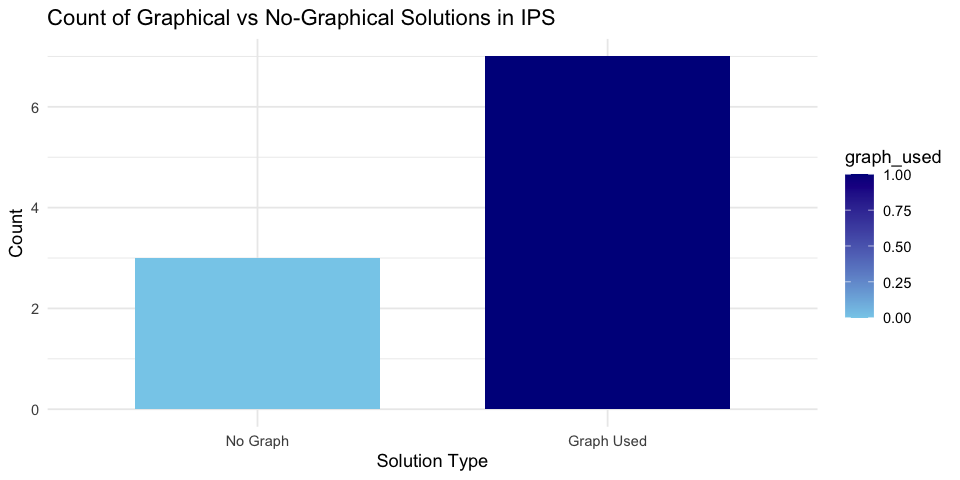

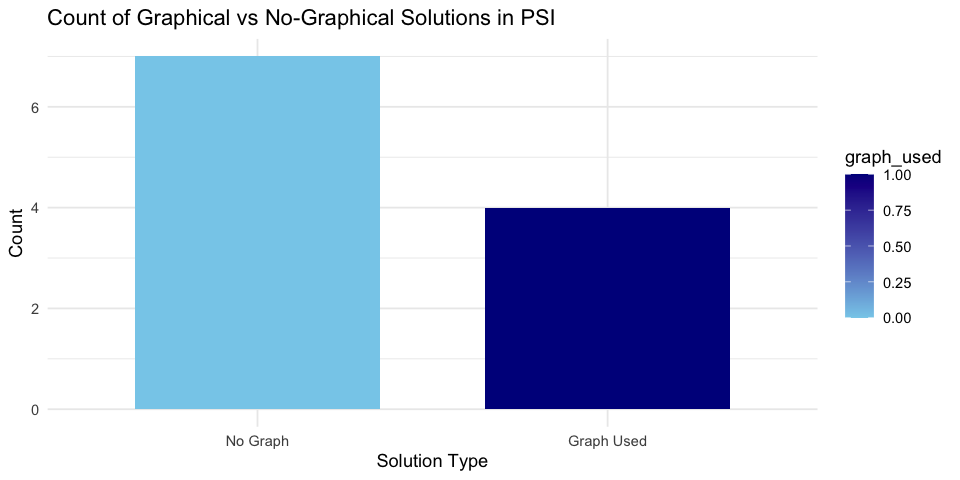

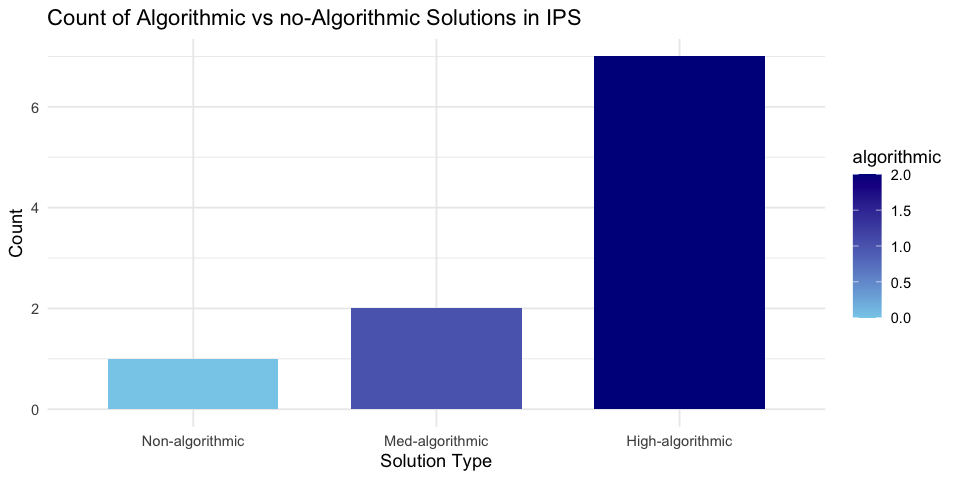

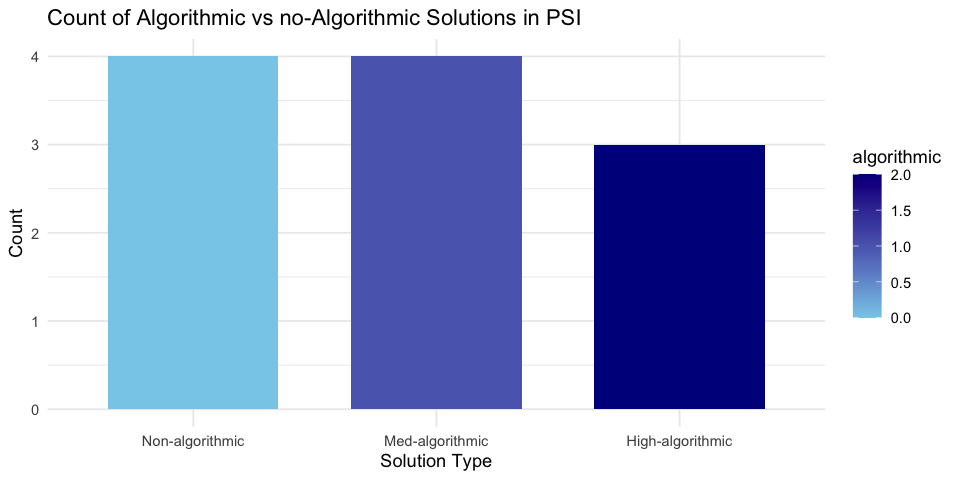

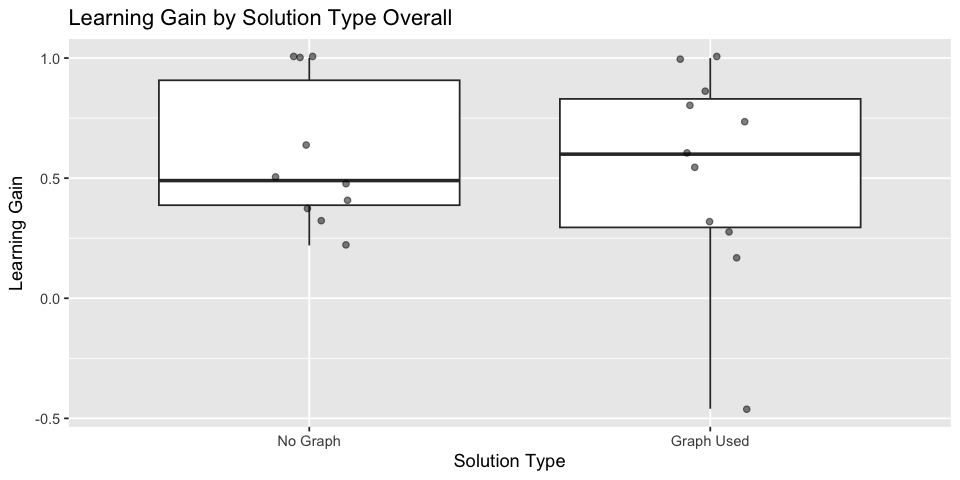

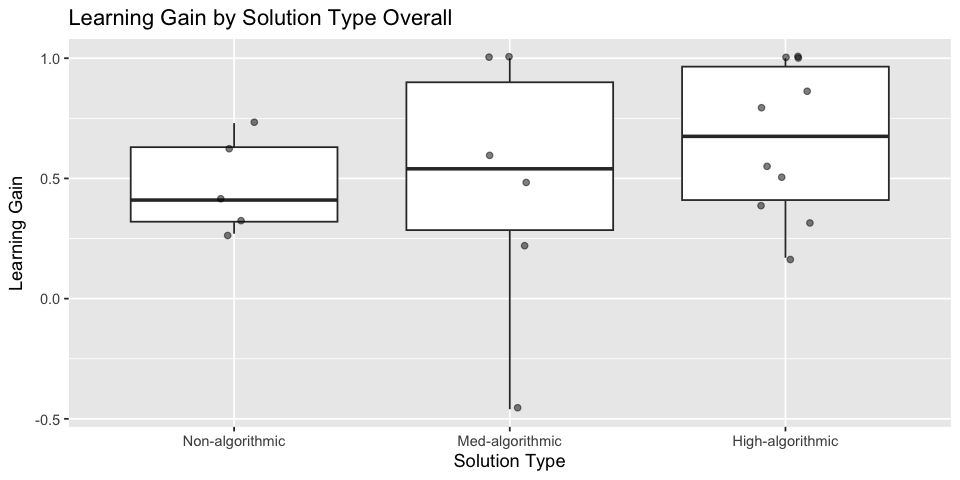

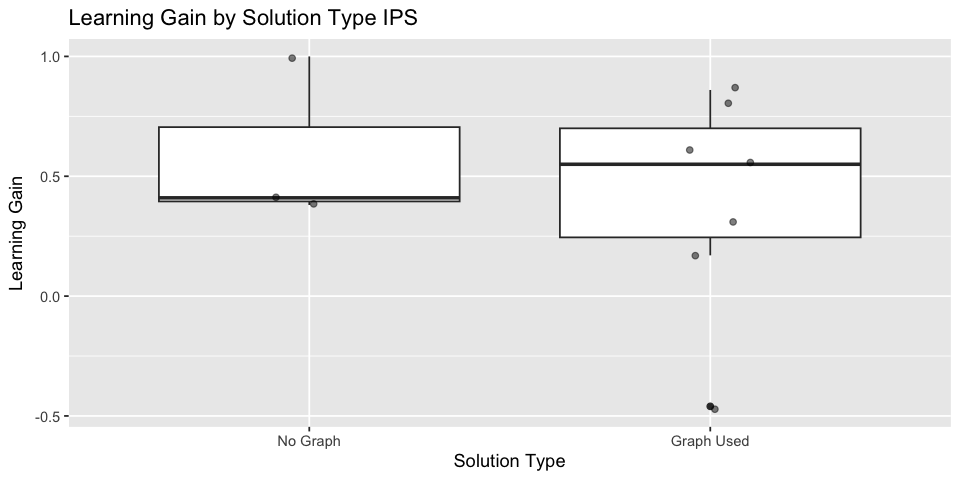

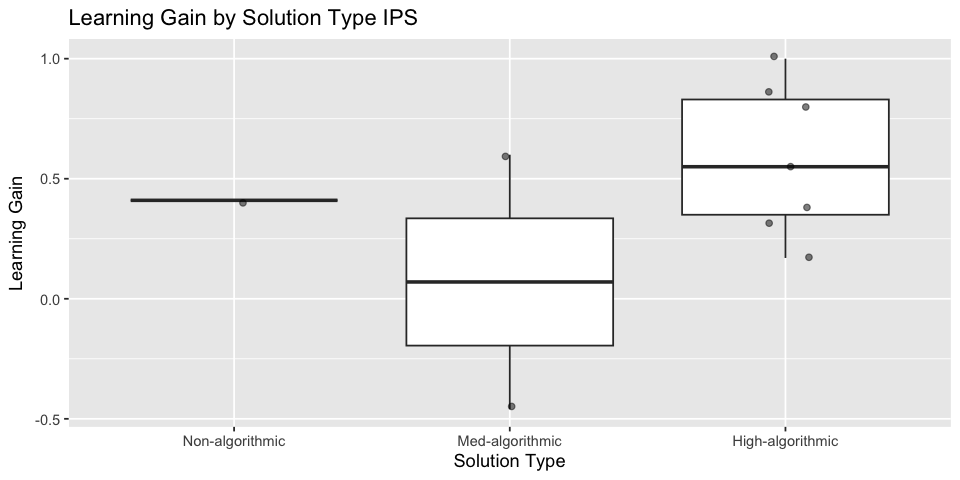

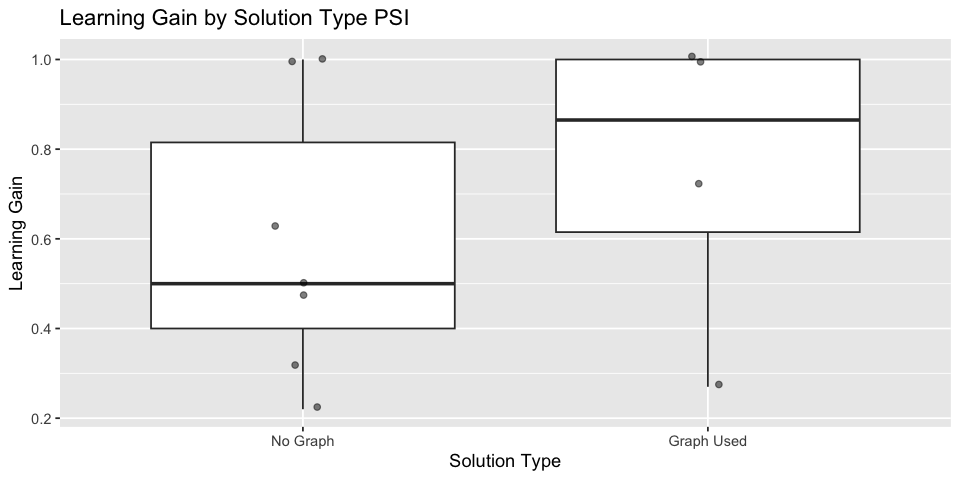

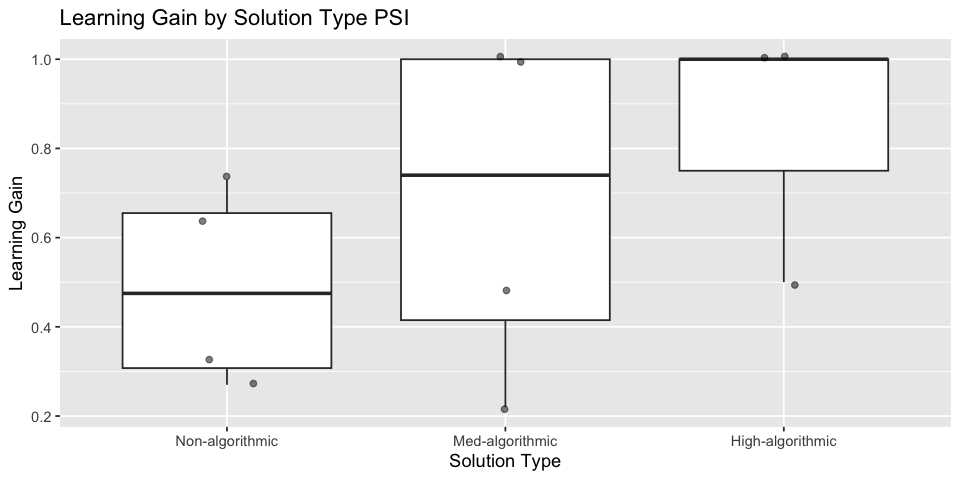

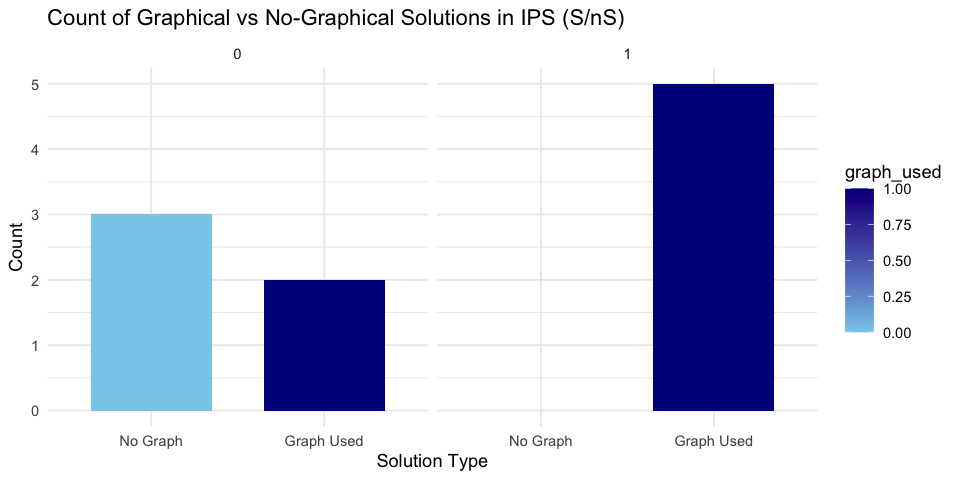

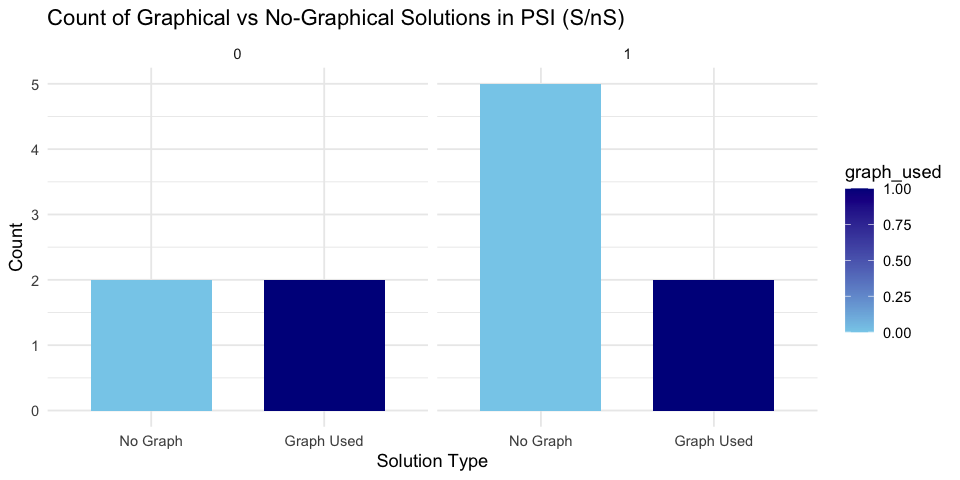

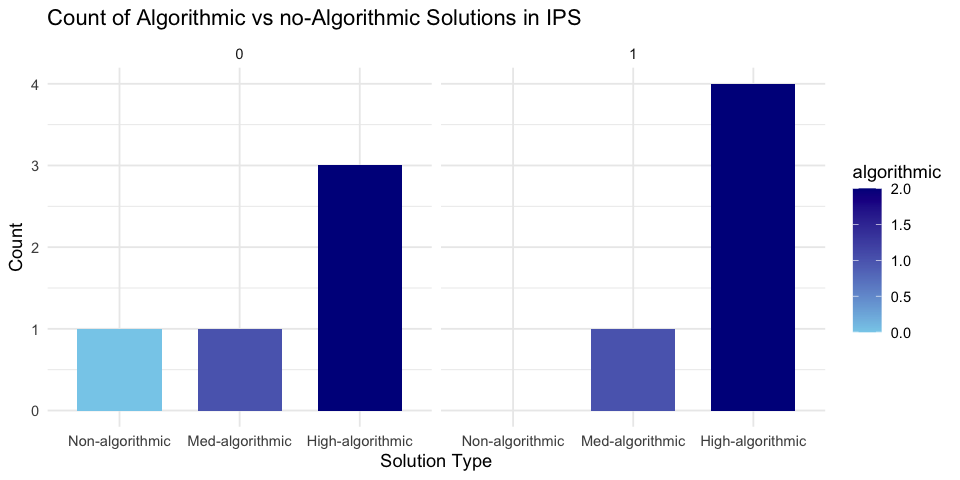

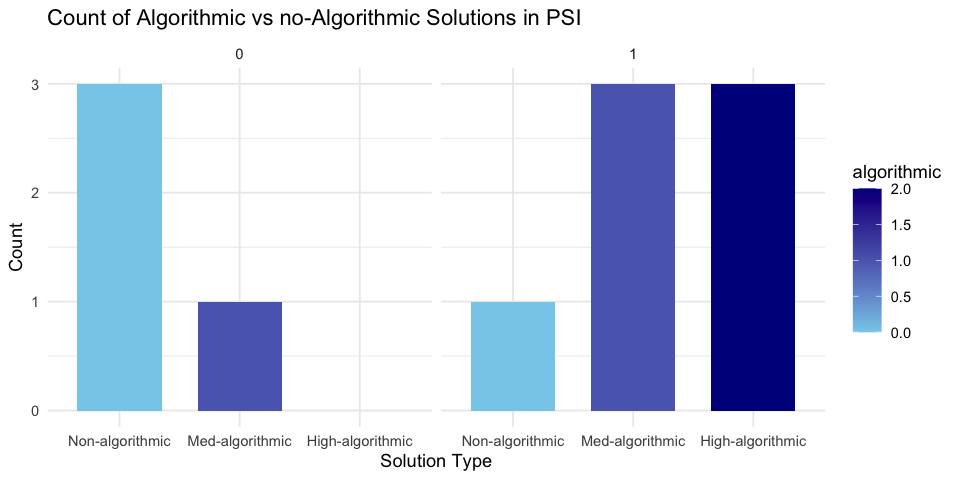

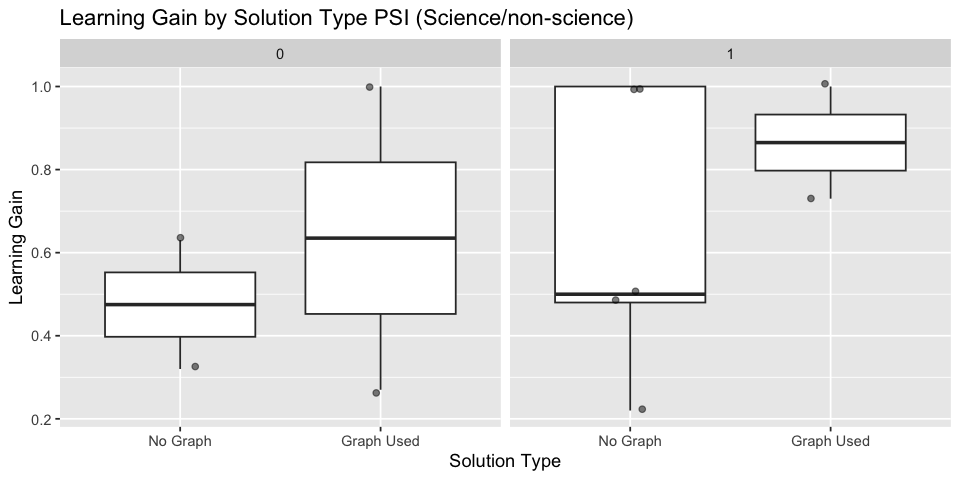

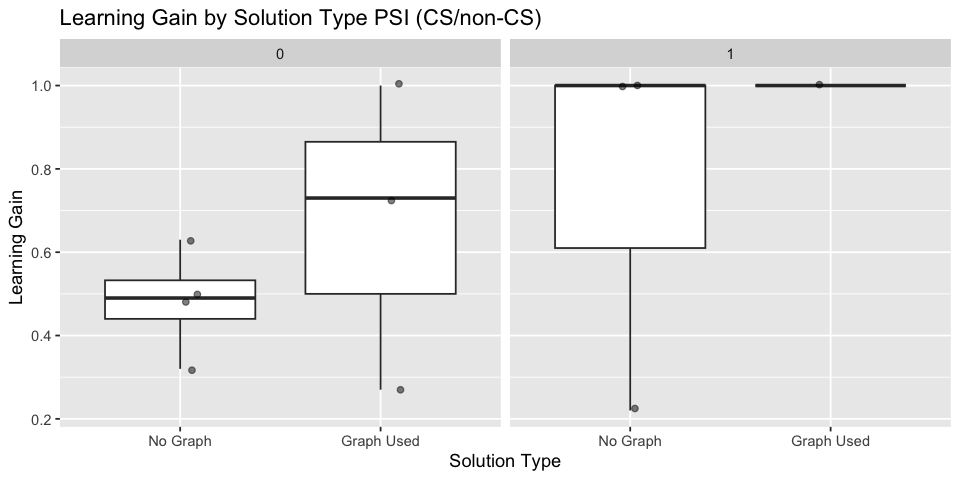

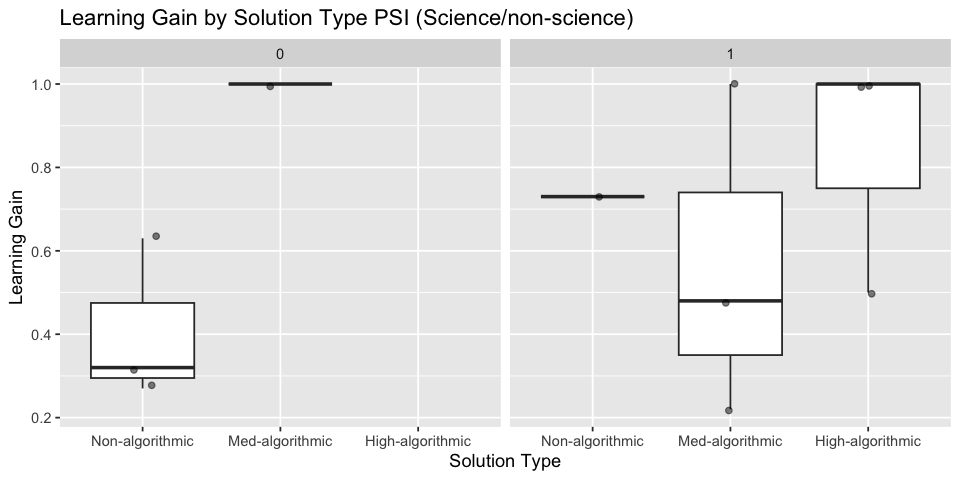

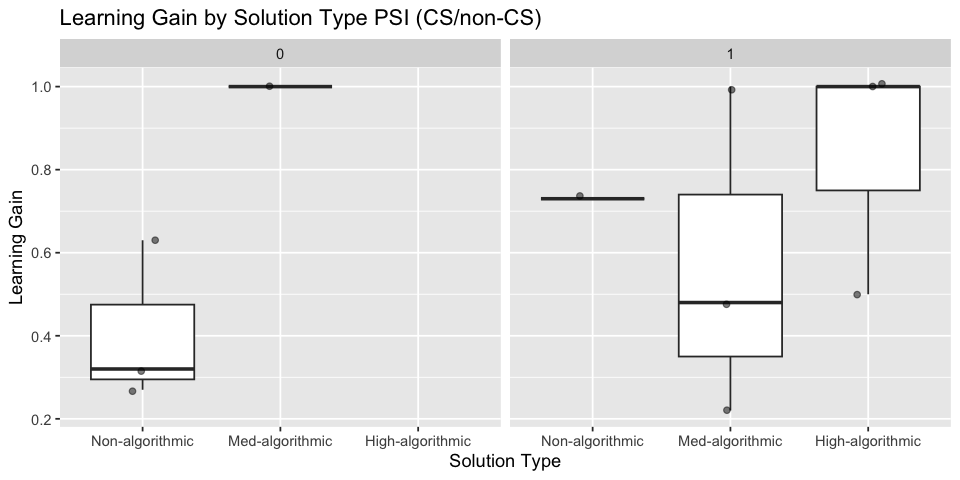

In [172]:
options(repr.plot.width=8, repr.plot.height=4)

# impact of PSI/IPS on graphical and algorithmic solutions 
# count of graphical vs no graphical in IPS
df_combined %>%
filter(group == "ips") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs No-Graphical Solutions in IPS",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()

# count of graphical vs no graphical in PSI
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs No-Graphical Solutions in PSI",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()

# count of Algorithmic vs no Algorithmic in IPS
df_combined %>%
filter(group == "ips") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs no-Algorithmic Solutions in IPS",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  theme_minimal()

# count of Algorithmic vs no Algorithmic in PSI
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs no-Algorithmic Solutions in PSI",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  theme_minimal()

# impact of graphical and algorithmic solutions on Learning Gain (overall)
ggplot(df_combined, aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  labs(title = "Learning Gain by Solution Type Overall",
       x = "Solution Type",
       y = "Learning Gain")

ggplot(df_combined, aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  labs(title = "Learning Gain by Solution Type Overall",
       x = "Solution Type",
       y = "Learning Gain")

# impact of graphical and algorithmic solutions on Learning Gain (IPS)
df_combined %>%
filter(group == "ips") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  labs(title = "Learning Gain by Solution Type IPS",
       x = "Solution Type",
       y = "Learning Gain")

df_combined %>%
filter(group == "ips") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  labs(title = "Learning Gain by Solution Type IPS",
       x = "Solution Type",
       y = "Learning Gain")

# impact of graphical and algorithmic solutions on Learning Gain (PSI)
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  labs(title = "Learning Gain by Solution Type PSI",
       x = "Solution Type",
       y = "Learning Gain")

df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  labs(title = "Learning Gain by Solution Type PSI",
       x = "Solution Type",
       y = "Learning Gain")


# Moderation impact of Scientific background on impact of PSi/IPS on graphical nad algorithmic solutions 
# i.e., Do ppl with scientific background tend to provide more or less graphical and/or algorithmic solutions in PSI/IPS

# a) count of graphical vs no graphical in IPS
df_combined %>%
filter(group == "ips") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs No-Graphical Solutions in IPS (S/nS)",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()

# b) count of graphical vs no graphical in PSI
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(graph_used), fill=graph_used)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Graphical vs No-Graphical Solutions in PSI (S/nS)",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  theme_minimal()

# c) count of Algorithmic vs no Algorithmic in IPS
df_combined %>%
filter(group == "ips") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs no-Algorithmic Solutions in IPS",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  theme_minimal()

# d) count of Algorithmic vs no Algorithmic in PSI
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(algorithmic), fill=algorithmic)) +
  geom_bar(width = 0.7) +
  labs(title = "Count of Algorithmic vs no-Algorithmic Solutions in PSI",
       x = "Solution Type",
       y = "Count") +
  scale_fill_gradient(low = "skyblue", high = "darkblue") +
  facet_wrap(~science) +
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  theme_minimal()

# Moderation impact of Scientific background on impact of graphical nad algorithmic solutions on Learning Gain
# i.e., Do graphs lead to high learning gain in general or for non-science majors or for lower academic levels like Bachelor?
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  facet_wrap(~ science) + 
  labs(title = "Learning Gain by Solution Type PSI (Science/non-science)",
       x = "Solution Type",
       y = "Learning Gain")

# The result for this graph can be ignored
df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(graph_used), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("No Graph", "Graph Used")) +
  facet_wrap(~ CS) + 
  labs(title = "Learning Gain by Solution Type PSI (CS/non-CS)",
       x = "Solution Type",
       y = "Learning Gain")

df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  facet_wrap(~ science) + 
  labs(title = "Learning Gain by Solution Type PSI (Science/non-science)",
       x = "Solution Type",
       y = "Learning Gain")

df_combined %>%
filter(group == "psi") %>%
ggplot(aes(x = factor(algorithmic), y = rel_learning_gain)) +
  geom_boxplot() +
  geom_jitter(width = 0.1, alpha = 0.5) + 
  scale_x_discrete(labels = c("Non-algorithmic", "Med-algorithmic", "High-algorithmic")) +
  facet_wrap(~ science) + 
  labs(title = "Learning Gain by Solution Type PSI (CS/non-CS)",
       x = "Solution Type",
       y = "Learning Gain")

# Results:
# 0- In IPS, there is higher number of graphical and algorithmic solutions than PSI
# 1- Graph usage does not have a big impact on learning gain in case of IPS but higher iN PSI, 
# possibly because in PSI, graph usage leads to higher engagement and understanding and exploration 
# But in IPS, ppl use graphs just bec they saw it in the lecture, so it does not lead to deeper engagement & exploration
# 2- The higher the algorithmic, the higher the learning gain in PSI, but in IPS is not related. Likely same reason as in (1)
# 3- IN PS, graph increases learning gain for non science majors more than science ones
# 4- algorithmic sols however increases learning gain only for Science & CS but has no visible impact on no science majors
# 5- In pSI, science studets provides less graphical but more algorithmic solutions han non-scinece ones
# IN IPS, however, science students slightly provided more algorithmic than non science (not big diff)



## Interest Level Visulatization

`geom_smooth()` using formula = 'y ~ x'


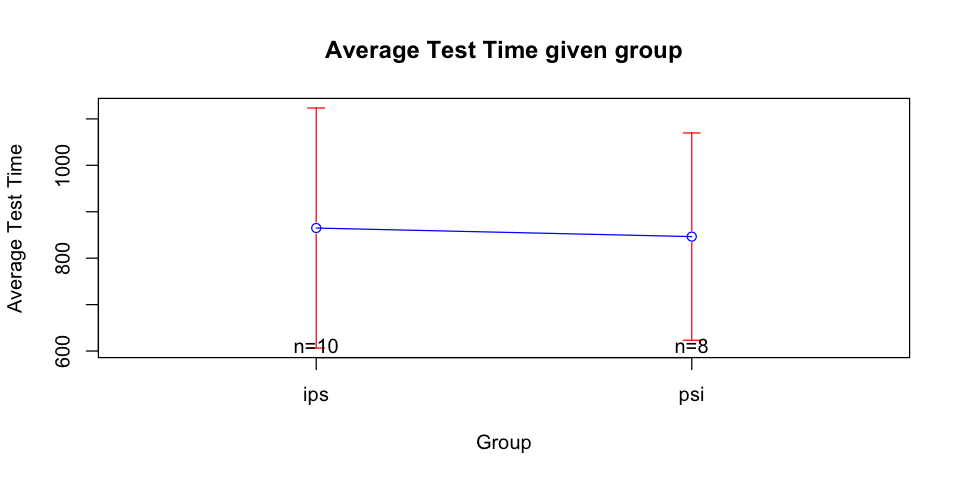

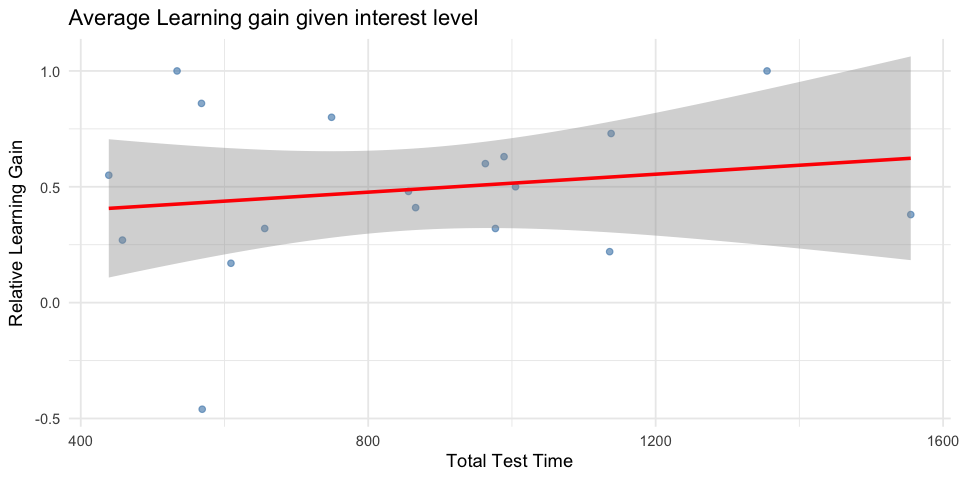

In [182]:
# In this analysis, we use time spent in pre-test & post-yest as indication of interest level
# We exclude ppl with pre-test scores >= 7 as they already know a lot and might spend less time bec they know not bec they are'nt interested
# We acknowledge that these factors might not be enough in practice to measure interest level and it is better to conduct this experiment in person to assess ppl facial expressions and engagement level
# in terms of body language, etc, which is hard to assess online 

# Impact of PSI/IPS on interest level (Does interest level changes depending on whether it is PSI or IPS)
par(bg = "white")

df_combined %>%
  filter(grade_pretest < 7) %>%
  mutate(total_time = time_pretest + time_posttest) %>%
  plotmeans(total_time ~ group, 
            data = .,
            main = "Average Test Time given group",
            ylab = "Average Test Time",
            xlab = "Group",
            col = "blue",
            barcol = "red")

# Impact of Interest Level on learning gain
df_combined %>%
  filter(grade_pretest < 7) %>%
  mutate(total_time = time_pretest + time_posttest) %>%
ggplot(aes(x = total_time, y = rel_learning_gain)) +
  geom_point(alpha = 0.6, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Average Learning gain given interest level",
    x = "Total Test Time",
    y = "Relative Learning Gain"
  ) +
  theme_minimal()

# Results
# 1- PSI/IPS do not impact the interest level
# 2- could not see big direct relation between total test time or interest level and laerning gain (very slight direct relation)


## Mediation-Moderation Analysis

### PART 1: Mediation only

In [190]:

# TODO: add rest of mediators
library(mediation)

# 1- graph_use impact in general & for PSI only 
summary(model.0)


Call:
lm(formula = rel_learning_gain ~ group, data = df_combined)

Residuals:
   Min     1Q Median     3Q    Max 
-0.923 -0.170 -0.020  0.350  0.537 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.4630     0.1156   4.004 0.000759 ***
grouppsi      0.1870     0.1598   1.170 0.256273    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.3656 on 19 degrees of freedom
Multiple R-squared:  0.06726,	Adjusted R-squared:  0.01817 
F-statistic:  1.37 on 1 and 19 DF,  p-value: 0.2563


In [202]:

graph_model.a <- lm(graph_used ~ group, data = df_combined)
graph_model.c_dash <- lm(rel_learning_gain ~ group * graph_used, data = df_combined)

results <- mediate(graph_model.a, graph_model.c_dash,
treat = "group",
mediator = "graph_used",
boot = FALSE, sims = 2000, # change to TRUE to get bootstrapped results
control.value = "ips",
treat.value = "psi"
)
summary(results)

# 2- sol_strategy (algorithmic or not?)


Causal Mediation Analysis 

Quasi-Bayesian Confidence Intervals

                         Estimate 95% CI Lower 95% CI Upper p-value
ACME (control)            0.06371     -0.10942         0.33    0.54
ACME (treated)           -0.05403     -0.29251         0.12    0.56
ADE (control)             0.23836     -0.15656         0.68    0.23
ADE (treated)             0.12062     -0.30217         0.53    0.56
Total Effect              0.18433     -0.19482         0.55    0.32
Prop. Mediated (control)  0.15126     -3.19236         3.91    0.67
Prop. Mediated (treated) -0.11701     -4.55426         3.67    0.70
ACME (average)            0.00484     -0.13675         0.15    0.94
ADE (average)             0.17949     -0.20182         0.57    0.33
Prop. Mediated (average)  0.01712     -2.48318         2.21    0.93

Sample Size Used: 21 


Simulations: 2000 
